## **Libraries**

In [ ]:
# Core Libraries
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Encoding
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    OneHotEncoder,
    LabelEncoder
)

# Pipeline & Column Transformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## **Data nspection & Understanding**

**Objective:**  
Understand the dataset structure, feature types, and potential issues  
without performing any preprocessing or modification.


In [ ]:
df = pd.read_csv("Heart_disease.csv")
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,NaN
2,No,NaN,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [18]:
df.shape

(16859, 18)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16859 entries, 0 to 16858
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   HeartDisease      16859 non-null  object 
 1   BMI               15255 non-null  float64
 2   Smoking           16859 non-null  object 
 3   AlcoholDrinking   16859 non-null  object 
 4   Stroke            16859 non-null  object 
 5   PhysicalHealth    16859 non-null  int64  
 6   MentalHealth      16859 non-null  int64  
 7   DiffWalking       16854 non-null  object 
 8   Sex               16859 non-null  object 
 9   AgeCategory       16859 non-null  object 
 10  Race              16859 non-null  object 
 11  Diabetic          16859 non-null  object 
 12  PhysicalActivity  16859 non-null  object 
 13  GenHealth         16859 non-null  object 
 14  SleepTime         16355 non-null  float64
 15  Asthma            16859 non-null  object 
 16  KidneyDisease     16859 non-null  object

In [20]:
df.describe()

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,15255.000000,16859.000000,16859.000000,16355.000000
mean,28.380571,3.840085,3.867015,7.138490
std,6.410818,8.382590,7.962250,1.519619
min,12.400000,0.000000,0.000000,1.000000
25%,23.990000,0.000000,0.000000,6.000000
50%,27.390000,0.000000,0.000000,7.000000
75%,31.620000,2.000000,3.000000,8.000000
max,83.000000,30.000000,30.000000,24.000000


###  Initial Observations

#### 1️⃣ Dataset Size
- Number of rows: 16,859
- Number of features: 18

This dataset represents a moderately sized medical dataset suitable for exploratory analysis and modeling.

---

#### 2️⃣ Missing Values
Missing values are present in the dataset:

- BMI: 1,604 missing values
- DiffWalking: 5 missing values
- SleepTime: 504 missing values
- SkinCancer: 1,164 missing values

Most features are complete, but a few medical and lifestyle-related features contain missing values that will require careful handling during preprocessing.

---

#### 3️⃣ Numerical Features
The following features are numerical:
- BMI (float)
- PhysicalHealth (int)
- MentalHealth (int)
- SleepTime (float)

Justification:  
These features represent continuous or count-based measurements related to physical condition, mental health, and sleep behavior.

---

#### 4️⃣ Categorical Features
The following features are categorical:
- HeartDisease (target)
- Smoking
- AlcoholDrinking
- Stroke
- DiffWalking
- Sex
- AgeCategory
- Race
- Diabetic
- PhysicalActivity
- GenHealth
- Asthma
- KidneyDisease
- SkinCancer

These features describe binary states, categories, or grouped demographic/health conditions.

---

###  Critical Thinking

#### Features that look numeric but should be categorical
- PhysicalHealth and MentalHealth represent the number of unhealthy days (0–30) and are numerical, but they are bounded counts and may behave differently from continuous variables.

---

#### Features that look categorical but have ordering
- AgeCategory (e.g., 40–44, 55–59, 80 or older)
- GenHealth (Poor < Fair < Good < Very good < Excellent)

Ordering matters because treating these features as nominal would ignore meaningful progression between categories.

---

#### Why is misclassifying a feature dangerous?
- Visualization: Choosing the wrong chart type can lead to misleading interpretations.
- Encoding: Incorrect encoding may introduce artificial relationships or destroy ordinal meaning.
- Model behavior: Models may assume false distances or relationships, leading to biased predictions.


##  **Visualization**

###  Target Variable Visualization


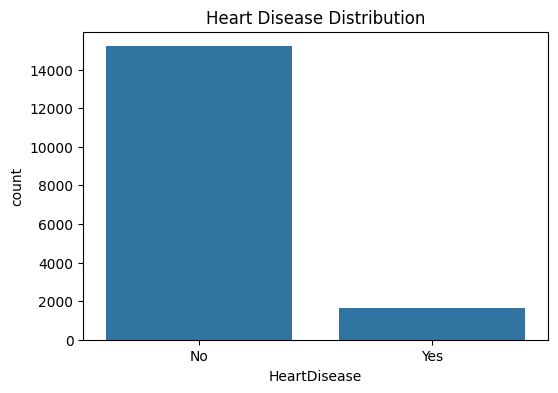

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="HeartDisease")
plt.title("Heart Disease Distribution")
plt.show()

###  Target Variable Analysis – HeartDisease

The target variable is clearly imbalanced.

- The number of individuals without heart disease (No) is significantly higher than those with heart disease (Yes).
- This indicates a strong class imbalance in the dataset.

**Impact of imbalance:**
- Model choice: Some models may become biased toward the majority class.
- Evaluation metrics: Accuracy alone would be misleading; metrics such as precision, recall, and F1-score would be more appropriate.


###  Numerical Feature Distribution


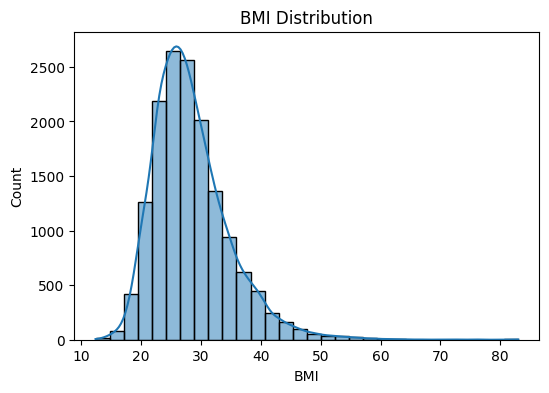

In [22]:
plt.figure(figsize=(6,4))
sns.histplot(df["BMI"], bins=30, kde=True)
plt.title("BMI Distribution")
plt.show()


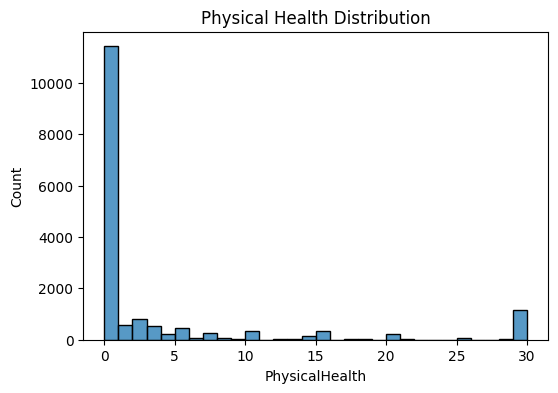

In [23]:
plt.figure(figsize=(6,4))
sns.histplot(df["PhysicalHealth"], bins=30, kde=False)
plt.title("Physical Health Distribution")
plt.show()

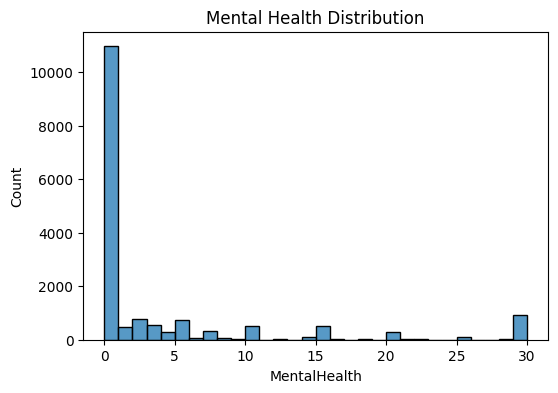

In [24]:
plt.figure(figsize=(6,4))
sns.histplot(df["MentalHealth"], bins=30, kde=False)
plt.title("Mental Health Distribution")
plt.show()

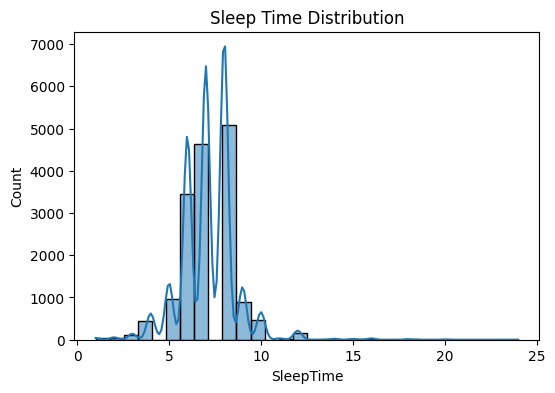

In [25]:
plt.figure(figsize=(6,4))
sns.histplot(df["SleepTime"], bins=30, kde=True)
plt.title("Sleep Time Distribution")
plt.show()

###  Numerical Feature Distribution – Summary

- **BMI** shows a right-skewed distribution with noticeable high-value outliers, indicating variability in body mass index across individuals. This suggests that scaling will be required, and robust scaling techniques may be more suitable.

- **PhysicalHealth** is heavily right-skewed, with most individuals reporting zero unhealthy physical health days. The presence of extreme values up to 30 days suggests outliers and a non-normal distribution.

- **MentalHealth** follows a similar pattern to PhysicalHealth, with a large concentration at zero and a long right tail, indicating significant skewness and potential outliers.

- **SleepTime** is approximately normally distributed, centered around 7–8 hours of sleep, with mild skewness and few extreme values. Standard scaling methods could be sufficient for this feature.


###  Categorical Feature Distribution


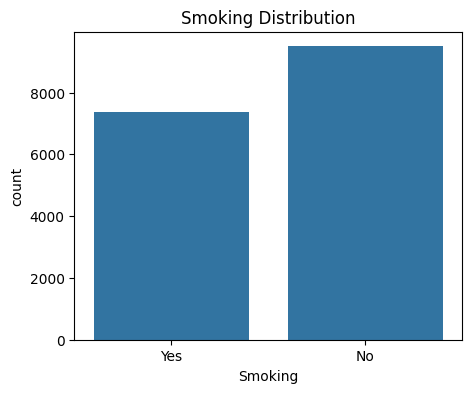

In [26]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Smoking")
plt.title("Smoking Distribution")
plt.show()

###  Categorical Feature Distribution – Smoking

- The distribution shows a moderate imbalance between smokers and non-smokers.
- The majority of individuals report not smoking.
- This imbalance should be considered when analyzing the relationship between smoking and heart disease.


### **Feature vs Target Analysis**


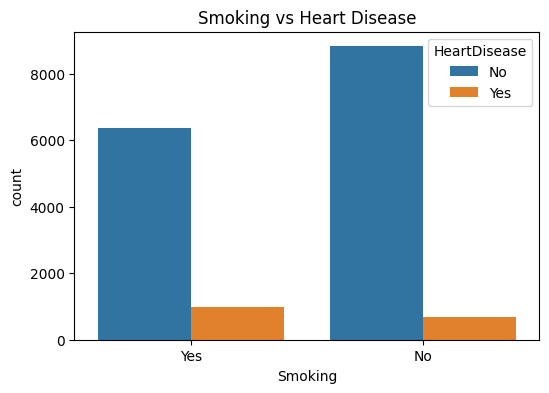

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Smoking", hue="HeartDisease")
plt.title("Smoking vs Heart Disease")
plt.show()

- Smokers show a higher proportion of heart disease compared to non-smokers.
- The difference between the two groups is visually clear.
- Smoking appears to be a strong candidate feature for predicting heart disease.

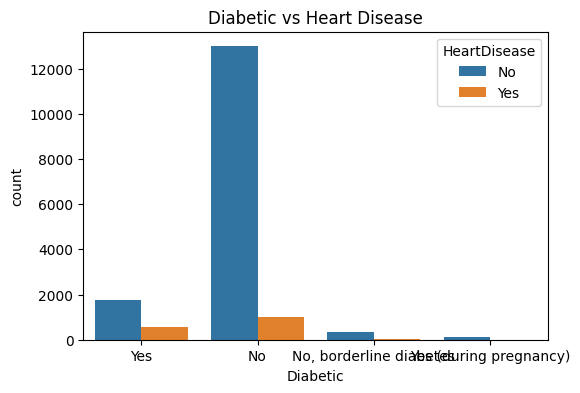

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Diabetic", hue="HeartDisease")
plt.title("Diabetic vs Heart Disease")
plt.show()

- Individuals with diabetes exhibit a noticeably higher rate of heart disease.
- The relationship is clear and consistent across categories.
- Diabetes is a strong candidate feature for heart disease prediction.

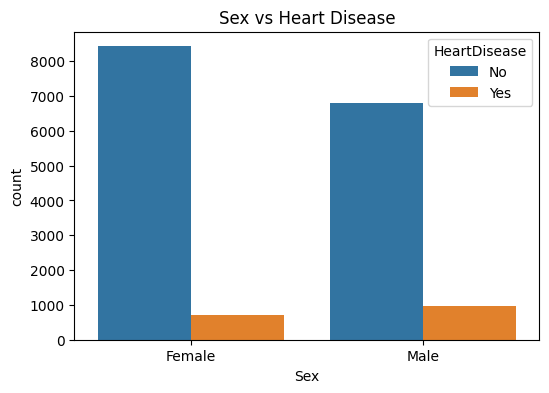

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Sex", hue="HeartDisease")
plt.title("Sex vs Heart Disease")
plt.show()

- Heart disease prevalence differs between males and females.
- One gender shows a higher proportion of heart disease.
- Sex may have moderate predictive value.

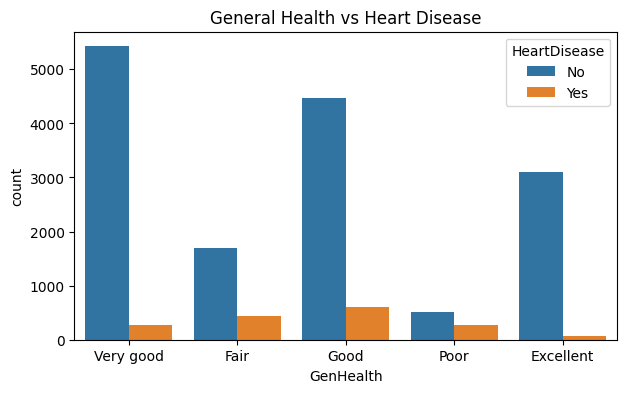

In [30]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="GenHealth", hue="HeartDisease")
plt.title("General Health vs Heart Disease")
plt.show()

- Poorer general health levels are associated with higher heart disease prevalence.
- A clear trend is visible across ordered health categories.
- GenHealth is a strong and meaningful predictor of heart disease.

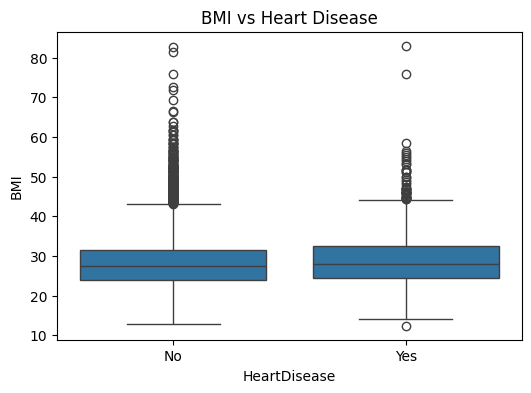

In [31]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="HeartDisease", y="BMI")
plt.title("BMI vs Heart Disease")
plt.show()

- Individuals with heart disease tend to have a slightly higher median BMI.
- The distributions overlap, but a shift in median is observable.
- BMI appears to have moderate predictive value for heart disease.

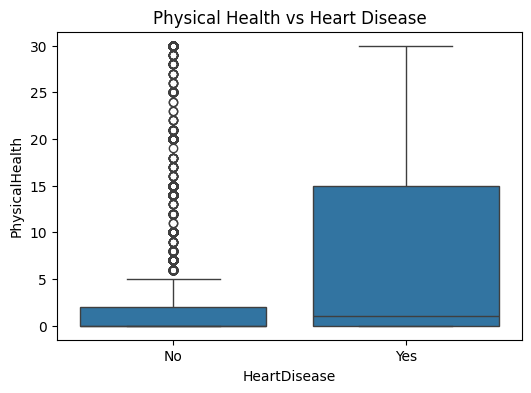

In [32]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="HeartDisease", y="PhysicalHealth")
plt.title("Physical Health vs Heart Disease")
plt.show()

- Individuals with heart disease report a higher number of poor physical health days.
- The median is clearly higher for the heart disease group.
- This feature shows a noticeable difference and may be a strong predictor.

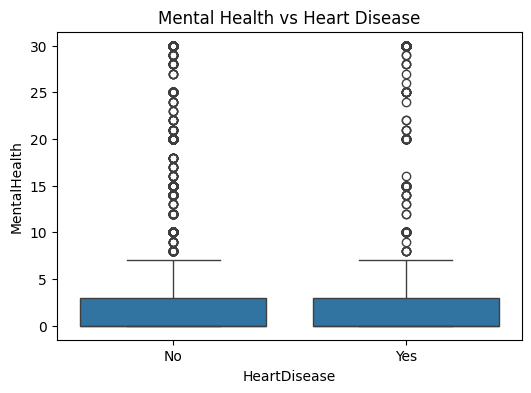

In [33]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="HeartDisease", y="MentalHealth")
plt.title("Mental Health vs Heart Disease")
plt.show()

- Individuals with heart disease tend to report more poor mental health days.
- However, the distributions overlap considerably.
- MentalHealth may have weak to moderate predictive value.

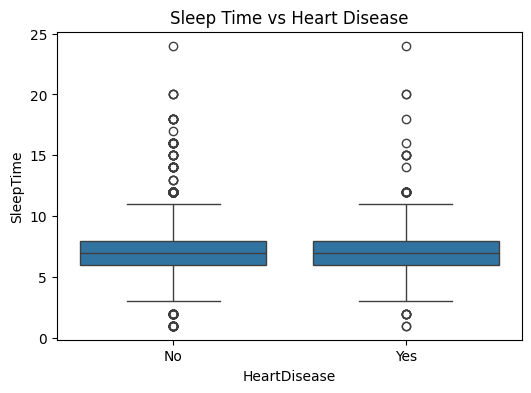

In [34]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="HeartDisease", y="SleepTime")
plt.title("Sleep Time vs Heart Disease")
plt.show()

- Individuals with heart disease tend to have slightly lower sleep duration.
- The difference in medians is small with significant overlap.
- SleepTime appears to have weak predictive power on its own.

Based on the visual analysis conducted in the previous sections, the dataset features can be grouped according to their expected predictive importance for heart disease.

### Strong Predictors
- Smoking  
- Diabetic  
- GenHealth  
- PhysicalHealth  

These features show clear and consistent differences between individuals with and without heart disease.

### Moderate Predictors
- BMI  
- Sex  
- MentalHealth  

These features demonstrate some separation between classes, but with noticeable overlap.

### Weak Predictors
- SleepTime  

This feature shows minimal difference between heart disease groups and may have limited predictive value on its own.

At this stage, no features are removed. Final feature selection decisions will be made after preprocessing and model evaluation.

##  **Data Preprocessing & Encoding**


In [35]:
df.isnull().sum()

HeartDisease           0
BMI                 1604
Smoking                0
AlcoholDrinking        0
Stroke                 0
PhysicalHealth         0
MentalHealth           0
DiffWalking            5
Sex                    0
AgeCategory            0
Race                   0
Diabetic               0
PhysicalActivity       0
GenHealth              0
SleepTime            504
Asthma                 0
KidneyDisease          0
SkinCancer          1164
dtype: int64

In [ ]:
num_cols = ["BMI", "SleepTime"]

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)


### Encoding Binary Categorical Features

Binary categorical features with two possible values (Yes/No) were encoded using label encoding.
This approach is appropriate since no inherent ordering exists between the categories.

In [37]:
from sklearn.preprocessing import LabelEncoder

binary_cols = [
    "Smoking", "AlcoholDrinking", "Stroke", "DiffWalking",
    "PhysicalActivity", "Asthma", "KidneyDisease", "SkinCancer",
    "HeartDisease"
]

le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])


### Encoding Ordinal Features

Ordinal categorical features were encoded manually to preserve their natural ordering.
This ensures that the numerical representation reflects the true relationship between categories.

In [38]:
genhealth_order = {
    "Poor": 0,
    "Fair": 1,
    "Good": 2,
    "Very good": 3,
    "Excellent": 4
}

df["GenHealth"] = df["GenHealth"].map(genhealth_order)


In [39]:
age_order = {
    "18-24": 0, "25-29": 1, "30-34": 2, "35-39": 3,
    "40-44": 4, "45-49": 5, "50-54": 6, "55-59": 7,
    "60-64": 8, "65-69": 9, "70-74": 10, "75-79": 11,
    "80 or older": 12
}

df["AgeCategory"] = df["AgeCategory"].map(age_order)


### One-Hot Encoding Nominal Features

Nominal categorical features without inherent ordering were encoded using one-hot encoding.
This prevents the model from assuming false ordinal relationships.

In [40]:
df = pd.get_dummies(df, columns=["Sex", "Race"], drop_first=True)

### Feature Scaling

Numerical features were scaled to ensure comparable ranges and prevent features with larger magnitudes from dominating the model.

RobustScaler was selected due to the presence of skewed distributions and outliers in several numerical features.

Binary and encoded categorical features were not scaled to preserve their semantic meaning.


In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

num_features = ["BMI", "PhysicalHealth", "MentalHealth", "SleepTime"]

df[num_features] = scaler.fit_transform(df[num_features])


## **Data Splitting, Leakage Awareness & Pipeline**


### Data Splitting Strategy

Due to class imbalance in the target variable, a stratified splitting strategy was selected.

Stratified splitting ensures that both training and testing sets contain the same proportion of heart disease classes, preventing biased evaluation.


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

num_features = ["BMI", "PhysicalHealth", "MentalHealth", "SleepTime"]

X_train[num_features] = scaler.fit_transform(X_train[num_features])
#10 mean 10 std


X_test[num_features] = scaler.transform(X_test[num_features])

### Final Preprocessing Pipeline

A pipeline-based approach was selected to ensure correct preprocessing order and prevent data leakage.

Using pipelines improves reproducibility, maintainability, and ensures that transformations are consistently applied during training and evaluation.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

numeric_features = ["BMI", "PhysicalHealth", "MentalHealth", "SleepTime"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", RobustScaler(), numeric_features)
    ],
    remainder="passthrough"
)

pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor)
])
